# [실습2] 인공지능 적용을 위한 데이터 분석 및 전처리 (정답)
---

## 실습 목표

- 데이터를 인공지능 모델이 해석할 수 있는 형태로 인코딩합니다.
- 데이터 간 상관관계를 분석하고 불필요한 데이터를 제거합니다.
- 데이터 정규화 및 표준화를 수행하고, 이를 저장하는 방법을 학습합니다.

---

## 실습 목차

1. **데이터 인코딩** 

2. **실습 데이터 불러오기 및 인코딩 적용** 

3. **데이터 상관관계 확인**

4. **피쳐 엔지니어링** 

5. **데이터 정규화 및 표준화** 

6. **데이터 압축 및 저장** 
---

## 실습 개요

이번 실습에서는 양극재 결정구조 분류 데이터셋에 전처리를 수행해볼 예정입니다. 전처리한 데이터는 인공지능 모델을 학습하는데에 사용됩니다.

---

## 1. 데이터 인코딩
---
먼저 지난 실습과 동일하게 토이 데이터를 먼저 이용하겠습니다.

In [43]:
## 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import scipy
import yellowbrick


In [44]:
df = pd.read_csv('./data/titanic.csv') # df: dataframe의 줄임말
display(df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


---
### 1.1 카테고리형 데이터 전처리
카테고리형 데이터(또는 범주형 데이터)는 인공지능 모델에서 해석할 수 있는 형태로 변형해주어야 합니다. 이러한 과정을 데이터 인코딩(data encoding)이라고 부릅니다.

카테고리형 데이터인 성별 데이터를 전처리해보겠습니다.

In [45]:
print(df['Sex'])

0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: Sex, Length: 891, dtype: object


In [46]:
df['Sex'].value_counts()

male      577
female    314
Name: Sex, dtype: int64

이와 같은 카테고리형 데이터는 수치 매핑 변환을 통해 인코딩할 수 있습니다. male을 0, femle을 1로 각각 매핑해보겠습니다.

In [47]:
df['SexMapping'] = df['Sex'].replace({'male': 0, 'female': 1})
print(df[['Sex', 'SexMapping']])

        Sex  SexMapping
0      male           0
1    female           1
2    female           1
3    female           1
4      male           0
..      ...         ...
886    male           0
887  female           1
888  female           1
889    male           0
890    male           0

[891 rows x 2 columns]


더미 기법을 이용해서 변환할 수도 있습니다.

In [48]:
dummies = pd.get_dummies(df['Sex'])
display(dummies)

,female,male
0,0,1
1,1,0
2,1,0
3,1,0
4,0,1
...,...,...
886,0,1
887,1,0
888,1,0
889,0,1


더미화하여 추가된 데이터를 기존 데이터와 합칩니다.

In [49]:
pd.concat([df, dummies], axis = 1)[['Sex', 'female', 'male']]

,Sex,female,male
0,male,0,1
1,female,1,0
2,female,1,0
3,female,1,0
4,male,0,1
...,...,...,...
886,male,0,1
887,female,1,0
888,female,1,0
889,male,0,1


이번에는 다른 방법으로 성별 데이터를 인코딩해보겠습니다.

아래와 같은 pandas 함수를 이용해 두 개 이상의 카테고리를 포함하는 카테고리형 데이터를 자동으로 번호를 매겨 변환할 수 있습니다.

In [50]:
df['Sex'] = df['Sex'].astype('category').cat.codes
display(df['Sex'])

0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Name: Sex, Length: 891, dtype: int8

동일한 방법을 이용해 Cabin 데이터를 인코딩해보겠습니다.

In [51]:
df['Cabin'] = df['Cabin'].astype('category').cat.codes
display(df['Cabin'])

0      -1
1      81
2      -1
3      55
4      -1
       ..
886    -1
887    30
888    -1
889    60
890    -1
Name: Cabin, Length: 891, dtype: int16

---
### 1.2 데이터 정규화
연속형 수치 데이터, 또는 숫자 데이터라고 불리는 데이터 항목은 0부터 1사이의 값을 가지도록 정규화 과정을 거쳐야 합니다.

정규화의 원리를 살펴보겠습니다.

In [52]:
df[['Fare']]

,Fare
0,7.2500
1,71.2833
2,7.9250
3,53.1000
4,8.0500
...,...
886,13.0000
887,30.0000
888,23.4500
889,30.0000


Fare 데이터를 정규화합니다. 정규화 식은 (데이터 - 최솟값) / (최댓값 - 최솟값) 을 따릅니다.

In [53]:
# (X - min) / (max - min)
df['FareNormalized'] = (df['Fare'] - df['Fare'].min()) / (df['Fare'].max())
display(df['FareNormalized'])

0      0.014151
1      0.139136
2      0.015469
3      0.103644
4      0.015713
         ...   
886    0.025374
887    0.058556
888    0.045771
889    0.058556
890    0.015127
Name: FareNormalized, Length: 891, dtype: float64

In [54]:
print("최솟값: ", df['FareNormalized'].min())
print("최댓값: ", df['FareNormalized'].max())

최솟값:  0.0
최댓값:  1.0


Fare데이터가 0부터 1사이의 값으로 정규화되었습니다.

---

### 1.3 데이터 표준화
아래의 두 가지 이유로, 모든 숫자 데이터를 정규 분포 형태로 표준화해야 합니다.
- 인공지능 모델은 숫자 데이터가 대략 -1에서 1의 범위를 갖는다고 가정하고 작동하는 경우가 많습니다. 
- 또, 데이터가 평균이 0이고 분산이 1인 정규 분포를 따른다고 가정하는 머신 러닝 기법들도 많습니다.

이어서 Fare 데이터를 표준화해보겠습니다.

In [55]:
df['FareNormalized']

0      0.014151
1      0.139136
2      0.015469
3      0.103644
4      0.015713
         ...   
886    0.025374
887    0.058556
888    0.045771
889    0.058556
890    0.015127
Name: FareNormalized, Length: 891, dtype: float64

Fare 데이터를 표준화합니다. 표준화 식은 (데이터 - 평균) / 표준편차 를 따릅니다.

In [56]:
# (X - X_mean) / X_std
df['FareStandarized'] = (df['FareNormalized'] - df['FareNormalized'].mean()) / df['FareNormalized'].std()
display(df['FareStandarized'])

0     -0.502163
1      0.786404
2     -0.488580
3      0.420494
4     -0.486064
         ...   
886   -0.386454
887   -0.044356
888   -0.176164
889   -0.044356
890   -0.492101
Name: FareStandarized, Length: 891, dtype: float64

In [57]:
print("평균: ", df['FareStandarized'].mean())
print("표준편차: ", df['FareStandarized'].std())

평균:  -5.958570711287877e-16
표준편차:  1.0000000000000004


Fare 데이터가 성공적으로 표준화되었습니다. 평균은 0, 표준편차를 1을 따릅니다.

동일한 원리로 나이(Age) 데이터도 표준화해보겠습니다.

In [58]:
df['Age'] = (df['Age'] - df['Age'].mean()) / df['Age'].std()
display(df['Age'])

0     -0.530005
1      0.571430
2     -0.254646
3      0.364911
4      0.364911
         ...   
886   -0.185807
887   -0.736524
888         NaN
889   -0.254646
890    0.158392
Name: Age, Length: 891, dtype: float64

---
## 2. 실습 데이터 불러오기 및 인코딩 적용
---

나머지 실습은 실습 데이터를 이용해 진행하겠습니다. 동일하게 실습 데이터를 불러옵니다.

In [59]:
df = pd.read_csv('./data/lithium-ion batteries.csv') # df: dataframe의 줄임말
display(df)

,Materials Id,Formula,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Volume,Has Bandstructure,Crystal System
0,mp-849394,Li2MnSiO4,Pc,-2.699,0.006,3.462,16,2.993,178.513,True,monoclinic
1,mp-783909,Li2MnSiO4,P21/c,-2.696,0.008,2.879,32,2.926,365.272,True,monoclinic
2,mp-761311,Li4MnSi2O7,Cc,-2.775,0.012,3.653,28,2.761,301.775,True,monoclinic
3,mp-761598,Li4Mn2Si3O10,C2/c,-2.783,0.013,3.015,38,2.908,436.183,True,monoclinic
4,mp-767709,Li2Mn3Si3O10,C2/c,-2.747,0.016,2.578,36,3.334,421.286,True,monoclinic
...,...,...,...,...,...,...,...,...,...,...,...
334,mp-764961,Li6Co(SiO4)2,P1,-2.545,0.071,2.685,17,2.753,171.772,True,triclinic
335,mp-849520,LiCo3(SiO4)2,P1,-2.250,0.076,0.005,42,3.318,552.402,True,triclinic
336,mp-849656,Li5Co4(Si3O10)2,P1,-2.529,0.082,0.176,35,2.940,428.648,True,triclinic
337,mp-763557,LiCoSiO4,P1,-2.348,0.087,1.333,14,2.451,214.044,True,triclinic


---
### 2.1 데이터 카테고리화
데이터를 카테고리화(categoize)합니다.

데이터가 object(string) 형태인 경우, 이미 그 상태로 카테고리화가 되어있으므로 고려하지 않아도 됩니다.

하지만 만약 숫자 데이터의 항목 전체가 단 몇 개의 숫자로만 이뤄져 있다면, 즉 고유값의 갯수가 매우 적다면, 두 가지 상황 중 하나로 여길 수 있습니다.
1. 데이터가 불연속적이다 (ex. 정수).
2. 데이터가 연속적이더라도, 데이터를 상황별로 분류하여 받아들이는 것이 더 합당하다.
이러할 경우, 이를 카테고리 형 데이터(Categorical Data) 라고 부릅니다.

가장 대표적인 예시는 바로 참/거짓만 포함하는 bool 타입니다. 참은 1, 거짓은 0인 숫자로 취급되고, 따라서 고유값의 갯수가 2 이기 때문입니다.

따라서, 숫자 타입의 카테고리 형 데이터와 문자열 타입의 데이터를 카테고리화(categorize) 해야 합니다.

threshold_cat 변수는 사용자가 정의하는 임계값입니다. 고유값 갯수가 5 이하인 경우, 카테고리 형 데이터로 취급하겠습니다.

위 실습에서 사용했던 pandas의 기능인 cat.codes 를 사용하겠습니다.


In [60]:
from pandas.api.types import is_numeric_dtype # float, int, bool 인지 확인

threshold_cat = 5

def num_encoding(df, threshold_cat):
    for c in df.columns:
        if is_numeric_dtype(df[c]): 
            # float64, int64, bool 등 숫자 데이터일 경우
            if df[c].unique().shape[0] <= threshold_cat: 
                # 임계값 이하의 숫자로만 데이터가 이뤄진 경우
                print('카테고리형 데이터를 인코딩합니다. 데이터: ', c)
                df[c] = df[c].astype('category').cat.codes
            else:
                # 연속적인 숫자 데이터인 경우
                print('인코딩할 필요가 없는 숫자형 데이터입니다. 데이터:', c)
    return df

In [61]:
df = num_encoding(df, threshold_cat)
display(df)

인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: Formation Energy (eV)
인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: E Above Hull (eV)
인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: Band Gap (eV)
인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: Nsites
인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: Density (gm/cc)
인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: Volume
카테고리형 데이터를 인코딩합니다. 데이터:  Has Bandstructure


,Materials Id,Formula,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Volume,Has Bandstructure,Crystal System
0,mp-849394,Li2MnSiO4,Pc,-2.699,0.006,3.462,16,2.993,178.513,1,monoclinic
1,mp-783909,Li2MnSiO4,P21/c,-2.696,0.008,2.879,32,2.926,365.272,1,monoclinic
2,mp-761311,Li4MnSi2O7,Cc,-2.775,0.012,3.653,28,2.761,301.775,1,monoclinic
3,mp-761598,Li4Mn2Si3O10,C2/c,-2.783,0.013,3.015,38,2.908,436.183,1,monoclinic
4,mp-767709,Li2Mn3Si3O10,C2/c,-2.747,0.016,2.578,36,3.334,421.286,1,monoclinic
...,...,...,...,...,...,...,...,...,...,...,...
334,mp-764961,Li6Co(SiO4)2,P1,-2.545,0.071,2.685,17,2.753,171.772,1,triclinic
335,mp-849520,LiCo3(SiO4)2,P1,-2.250,0.076,0.005,42,3.318,552.402,1,triclinic
336,mp-849656,Li5Co4(Si3O10)2,P1,-2.529,0.082,0.176,35,2.940,428.648,1,triclinic
337,mp-763557,LiCoSiO4,P1,-2.348,0.087,1.333,14,2.451,214.044,1,triclinic


---
### 2.2 글자 데이터 인코딩
데이터가 object(string) 형태인 글자 데이터의 경우, 인공지능 모델에서 해석할 수 있는 형태인 숫자로 변환해줍니다. 이렇게 데이터를 변환해주는 과정을 데이터 인코딩(encoding)이라고 합니다. 



In [62]:
def str_encoding(df):
    for c in df.columns:
        if df[c].dtypes == 'object' or df[c].dtypes.name == 'category': 
           print('글자 데이터를 인코딩합니다. 데이터:', c)
           df[c] = df[c].factorize()[0].astype(np.int32)
    return df

In [63]:
df = str_encoding(df)
display(df)

글자 데이터를 인코딩합니다. 데이터: Materials Id
글자 데이터를 인코딩합니다. 데이터: Formula
글자 데이터를 인코딩합니다. 데이터: Spacegroup
글자 데이터를 인코딩합니다. 데이터: Crystal System


,Materials Id,Formula,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Volume,Has Bandstructure,Crystal System
0,0,0,0,-2.699,0.006,3.462,16,2.993,178.513,1,0
1,1,0,1,-2.696,0.008,2.879,32,2.926,365.272,1,0
2,2,1,2,-2.775,0.012,3.653,28,2.761,301.775,1,0
3,3,2,3,-2.783,0.013,3.015,38,2.908,436.183,1,0
4,4,3,3,-2.747,0.016,2.578,36,3.334,421.286,1,0
...,...,...,...,...,...,...,...,...,...,...,...
334,334,111,43,-2.545,0.071,2.685,17,2.753,171.772,1,2
335,335,112,43,-2.250,0.076,0.005,42,3.318,552.402,1,2
336,336,113,43,-2.529,0.082,0.176,35,2.940,428.648,1,2
337,337,54,43,-2.348,0.087,1.333,14,2.451,214.044,1,2


---
## 3. 데이터 상관관계 확인
### 3.1 기본 상태에서 상관관계 확인
데이터 간의 상관관계(correlation)을 확인합니다. 데이터 간의 상관관계를 확인하는 것은 중요한 데이터 분석 단계 중 하나입니다. 상관관계란 두 변수가 어떻게 함께 움직이는지, 즉 한 변수의 변화가 다른 변수의 변화와 어떤 관계를 가지는지를 알아보는 것을 의미합니다.

상관관계를 확인하면 데이터를 더 잘 이해할 수 있고, 예상하지 못한 패턴을 발견할 수도 있습니다.

In [64]:
corr = df.corr() 
corr.style.background_gradient(cmap='coolwarm')

,Materials Id,Formula,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Volume,Has Bandstructure,Crystal System
Materials Id,1.000000,0.588513,0.897105,0.168878,0.205312,-0.178904,-0.011202,0.130430,-0.013843,0.038055,0.927930
Formula,0.588513,1.000000,0.477374,0.285640,0.223831,-0.232847,0.074695,0.092797,0.082929,-0.072575,0.456263
Spacegroup,0.897105,0.477374,1.000000,0.023937,0.142385,-0.163022,-0.012620,0.119096,-0.017846,0.037261,0.945752
Formation Energy (eV),0.168878,0.285640,0.023937,1.000000,0.272422,-0.438429,-0.270777,0.485055,-0.305389,0.198019,-0.009504
E Above Hull (eV),0.205312,0.223831,0.142385,0.272422,1.000000,-0.468094,0.068422,-0.022966,0.097230,-0.087987,0.066552
Band Gap (eV),-0.178904,-0.232847,-0.163022,-0.438429,-0.468094,1.000000,0.104626,-0.348753,0.152620,0.021514,-0.147028
Nsites,-0.011202,0.074695,-0.012620,-0.270777,0.068422,0.104626,1.000000,-0.178178,0.980329,-0.550676,-0.000647
Density (gm/cc),0.130430,0.092797,0.119096,0.485055,-0.022966,-0.348753,-0.178178,1.000000,-0.293185,0.188391,0.124988
Volume,-0.013843,0.082929,-0.017846,-0.305389,0.097230,0.152620,0.980329,-0.293185,1.000000,-0.566325,-0.012862
Has Bandstructure,0.038055,-0.072575,0.037261,0.198019,-0.087987,0.021514,-0.550676,0.188391,-0.566325,1.000000,0.021126


위의 Correlation Map을 관찰하면 다음과 같은 결과를 얻을 수 있습니다.

1. 데이터 본인과의 상관관계는 1.0 이다. (본인과는 100% 연관이 있기 때문에 당연한 결과입니다.)
2. Volume과 Nsites 데이터는 상관 관계가 매우 크다.
3. Materials Id와 Spacegroup 데이터는 상관 관계가 매우 크다.
4. Materials ID, Formula, Spacegroup 데이터는 정답 데이터인 Crystal System과 상관관계가 매우 크다.

하지만, 여기서 **데이터의 상관관계가 편향되지는 않았는지** 의심해봐야 합니다.

데이터를 처음부터 다시 불러, 데이터의 순서에 유의해서 관찰해봅시다.

In [65]:
df = pd.read_csv('./data/lithium-ion batteries.csv') # df: dataframe의 줄임말
display(df)

,Materials Id,Formula,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Volume,Has Bandstructure,Crystal System
0,mp-849394,Li2MnSiO4,Pc,-2.699,0.006,3.462,16,2.993,178.513,True,monoclinic
1,mp-783909,Li2MnSiO4,P21/c,-2.696,0.008,2.879,32,2.926,365.272,True,monoclinic
2,mp-761311,Li4MnSi2O7,Cc,-2.775,0.012,3.653,28,2.761,301.775,True,monoclinic
3,mp-761598,Li4Mn2Si3O10,C2/c,-2.783,0.013,3.015,38,2.908,436.183,True,monoclinic
4,mp-767709,Li2Mn3Si3O10,C2/c,-2.747,0.016,2.578,36,3.334,421.286,True,monoclinic
...,...,...,...,...,...,...,...,...,...,...,...
334,mp-764961,Li6Co(SiO4)2,P1,-2.545,0.071,2.685,17,2.753,171.772,True,triclinic
335,mp-849520,LiCo3(SiO4)2,P1,-2.250,0.076,0.005,42,3.318,552.402,True,triclinic
336,mp-849656,Li5Co4(Si3O10)2,P1,-2.529,0.082,0.176,35,2.940,428.648,True,triclinic
337,mp-763557,LiCoSiO4,P1,-2.348,0.087,1.333,14,2.451,214.044,True,triclinic


Crystal System 데이터를 관찰해보면, monoclinic, orthorhombic, triclinic 순서대로 데이터가 정렬된 것을 볼 수 있습니다.

이 상태에서 글자 데이터를 인코딩하면 다음과 같이 변환됩니다.

In [66]:
df = num_encoding(df, threshold_cat)
print("="*30)
df = str_encoding(df)

display(df)

인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: Formation Energy (eV)
인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: E Above Hull (eV)
인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: Band Gap (eV)
인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: Nsites
인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: Density (gm/cc)
인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: Volume
카테고리형 데이터를 인코딩합니다. 데이터:  Has Bandstructure
글자 데이터를 인코딩합니다. 데이터: Materials Id
글자 데이터를 인코딩합니다. 데이터: Formula
글자 데이터를 인코딩합니다. 데이터: Spacegroup
글자 데이터를 인코딩합니다. 데이터: Crystal System


,Materials Id,Formula,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Volume,Has Bandstructure,Crystal System
0,0,0,0,-2.699,0.006,3.462,16,2.993,178.513,1,0
1,1,0,1,-2.696,0.008,2.879,32,2.926,365.272,1,0
2,2,1,2,-2.775,0.012,3.653,28,2.761,301.775,1,0
3,3,2,3,-2.783,0.013,3.015,38,2.908,436.183,1,0
4,4,3,3,-2.747,0.016,2.578,36,3.334,421.286,1,0
...,...,...,...,...,...,...,...,...,...,...,...
334,334,111,43,-2.545,0.071,2.685,17,2.753,171.772,1,2
335,335,112,43,-2.250,0.076,0.005,42,3.318,552.402,1,2
336,336,113,43,-2.529,0.082,0.176,35,2.940,428.648,1,2
337,337,54,43,-2.348,0.087,1.333,14,2.451,214.044,1,2


이전에 정답 데이터인 Crystal System과 상관 관계가 매우 높았던 세 가지 데이터 항목을 잘 관찰해봅시다.

글자 데이터인 Materials Id, Formula, Spacegroup는 숫자 0부터 차례대로 1씩 증가하며 인코딩되었습니다. 

이를 통해 유추할 수 있는 것은, 정답 데이터가 애초에 순서대로 정렬되어 있어서, 순서대로 번호가 매겨진 글자 데이터에 의도치 않은 중요성이 부여되었다는 사실입니다.

단적인 예시로, 현재 데이터에서는 Materials Id가 140 이하이면 monoclinic, 141이상이고 268이하이면 orthorhombic, 269 이상이면 triclinic로 분류하면 100% 정확도로 분류할 수 있습니다.

데이터 전처리를 할 때 이러한 편향을 특히 조심해야 하며, 의도적으로 제거해주어야 합니다.

위와 같은 문제는 데이터를 인코딩 하기 전에 순서를 섞어줌으로써 간단하게 해결할 수 있습니다.

---

### 3.2 데이터 셔플(shuffle)
데이터의 순서를 의도적으로 섞어, 의도치 않은 편향을 막습니다.

In [67]:

df = pd.read_csv('./data/lithium-ion batteries.csv') # df: dataframe의 줄임말
df = df.sample(frac=1)  # row 전체 shuffle
df = df.sample(frac=1).reset_index(drop=True)  # shuffling하고 index reset
display(df)

,Materials Id,Formula,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Volume,Has Bandstructure,Crystal System
0,mp-764346,Li2FeSiO4,P21cn,-2.621,0.005,2.993,32,3.065,350.604,True,orthorhombic
1,mp-763360,Li2Co2(SiO3)3,Pnma,-2.574,0.094,2.842,64,3.249,735.894,True,orthorhombic
2,mp-762851,Li3Co2(SiO4)2,P1,-2.441,0.055,0.376,15,3.088,173.602,True,triclinic
3,mp-773691,LiFe(SiO3)2,P1,-2.785,0.036,2.596,80,3.251,878.288,False,triclinic
4,mp-865154,LiFe(Si3O7)2,Icma,-2.981,0.093,2.647,88,2.807,1077.384,False,orthorhombic
...,...,...,...,...,...,...,...,...,...,...,...
334,mp-763629,Li2FeSiO4,Pc,-2.621,0.005,3.027,16,3.073,174.862,True,monoclinic
335,mp-763389,Li2Co(SiO3)2,C2/c,-2.687,0.053,3.233,22,2.861,261.142,True,monoclinic
336,mp-780833,Li2MnSiO4,C2221,-2.691,0.014,2.962,16,2.882,185.391,True,orthorhombic
337,mp-763462,Li2Co3(SiO4)2,P1,-2.343,0.024,2.470,45,3.408,547.959,True,triclinic


데이터 셔플이 끝난 뒤, 동일하게 인코딩을 진행합니다.

In [68]:
df = num_encoding(df, threshold_cat)
print("="*30)
df = str_encoding(df)

display(df)

인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: Formation Energy (eV)
인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: E Above Hull (eV)
인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: Band Gap (eV)
인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: Nsites
인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: Density (gm/cc)
인코딩할 필요가 없는 숫자형 데이터입니다. 데이터: Volume
카테고리형 데이터를 인코딩합니다. 데이터:  Has Bandstructure
글자 데이터를 인코딩합니다. 데이터: Materials Id
글자 데이터를 인코딩합니다. 데이터: Formula
글자 데이터를 인코딩합니다. 데이터: Spacegroup
글자 데이터를 인코딩합니다. 데이터: Crystal System


,Materials Id,Formula,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Volume,Has Bandstructure,Crystal System
0,0,0,0,-2.621,0.005,2.993,32,3.065,350.604,1,0
1,1,1,1,-2.574,0.094,2.842,64,3.249,735.894,1,0
2,2,2,2,-2.441,0.055,0.376,15,3.088,173.602,1,1
3,3,3,2,-2.785,0.036,2.596,80,3.251,878.288,0,1
4,4,4,3,-2.981,0.093,2.647,88,2.807,1077.384,0,0
...,...,...,...,...,...,...,...,...,...,...,...
334,334,0,10,-2.621,0.005,3.027,16,3.073,174.862,1,2
335,335,23,4,-2.687,0.053,3.233,22,2.861,261.142,1,2
336,336,40,34,-2.691,0.014,2.962,16,2.882,185.391,1,0
337,337,112,2,-2.343,0.024,2.470,45,3.408,547.959,1,1


Crystal System이 무작위로 섞여, Materials Id, Space Group 등에 편향되지 않게 되었습니다.

---
### 3.3 데이터를 섞은 뒤 상관관계 분석
위와 동일하게 상관관계를 분석하여 correlation map을 관찰해봅시다.

In [69]:
corr = df.corr() 
corr.style.background_gradient(cmap='coolwarm')

,Materials Id,Formula,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Volume,Has Bandstructure,Crystal System
Materials Id,1.000000,0.265043,0.127308,0.051914,-0.103720,0.050526,-0.051788,0.085954,-0.045435,-0.011868,-0.078683
Formula,0.265043,1.000000,-0.122663,-0.107201,0.121713,-0.056951,0.135561,0.034770,0.136005,-0.126263,0.054621
Spacegroup,0.127308,-0.122663,1.000000,0.048884,-0.072165,0.129000,-0.019954,0.063491,-0.020961,0.080671,-0.275367
Formation Energy (eV),0.051914,-0.107201,0.048884,1.000000,0.272422,-0.438429,-0.270777,0.485055,-0.305389,0.198019,0.002527
E Above Hull (eV),-0.103720,0.121713,-0.072165,0.272422,1.000000,-0.468094,0.068422,-0.022966,0.097230,-0.087987,0.034298
Band Gap (eV),0.050526,-0.056951,0.129000,-0.438429,-0.468094,1.000000,0.104626,-0.348753,0.152620,0.021514,-0.059339
Nsites,-0.051788,0.135561,-0.019954,-0.270777,0.068422,0.104626,1.000000,-0.178178,0.980329,-0.550676,-0.175271
Density (gm/cc),0.085954,0.034770,0.063491,0.485055,-0.022966,-0.348753,-0.178178,1.000000,-0.293185,0.188391,-0.150098
Volume,-0.045435,0.136005,-0.020961,-0.305389,0.097230,0.152620,0.980329,-0.293185,1.000000,-0.566325,-0.148153
Has Bandstructure,-0.011868,-0.126263,0.080671,0.198019,-0.087987,0.021514,-0.550676,0.188391,-0.566325,1.000000,-0.041323


위 결과를 관찰하면 아래와 같은 결과가 사실이 아니었다는 것을 확인할 수 있습니다:

1. Materials Id와 Spacegroup 데이터는 상관 관계가 매우 크다.
2. Materials ID, Formula, Spacegroup 데이터는 정답 데이터인 Crystal System과 상관관계가 매우 크다.

데이터를 셔플한 뒤에도 여전히 나타나는 특성은 다음과 같습니다:

1. Volume과 Nsites 데이터는 상관 관계가 매우 크다.

상관관계가 매우 큰 데이터 항목의 경우, 그 중 하나만 선택해서 학습해도 무방합니다.

---
## 4. 피쳐 엔지니어링(Feature Engineering)
### 4.1 상관관계가 큰 데이터 항목 검출
상관관계가 매우 큰 데이터 조합을 찾고, 그 중 하나만 선택하고 나머지는 제거합니다.

threshold_corr 변수는 사용자가 정의하는 임계값입니다. 0.75 보다 더 큰 상관도를 갖는 데이터를 검출하겠습니다.

In [70]:
threshold_corr = 0.75

def correlated_columns(df, threshold_corr, target_col):
    df = df.drop(target_col, axis=1)
    corr_matrix = df.corr() 
    correlated_features=[]
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold_corr: 
               colname = corr_matrix.columns[i]
               correlated_features.append(colname)
    correlated_features = list(dict.fromkeys(correlated_features))
    return correlated_features

target_col 변수는 정답 데이터로 활용한 Crystal System을 의미합니다. 

혹시라도 정답 데이터가 상관도가 높은 데이터로 판별되어 삭제되는 경우를 사전에 방지합니다.

In [71]:
target_col = 'Crystal System'
correlated_features = correlated_columns(df, threshold_corr, target_col) 
print(correlated_features)

['Volume']


---
### 4.2 상관관계가 큰 데이터 항목 삭제
앞서 식별한 데이터 항목을 삭제합니다.

In [72]:
df = df.drop(correlated_features, axis=1)
display(df)

,Materials Id,Formula,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Has Bandstructure,Crystal System
0,0,0,0,-2.621,0.005,2.993,32,3.065,1,0
1,1,1,1,-2.574,0.094,2.842,64,3.249,1,0
2,2,2,2,-2.441,0.055,0.376,15,3.088,1,1
3,3,3,2,-2.785,0.036,2.596,80,3.251,0,1
4,4,4,3,-2.981,0.093,2.647,88,2.807,0,0
...,...,...,...,...,...,...,...,...,...,...
334,334,0,10,-2.621,0.005,3.027,16,3.073,1,2
335,335,23,4,-2.687,0.053,3.233,22,2.861,1,2
336,336,40,34,-2.691,0.014,2.962,16,2.882,1,0
337,337,112,2,-2.343,0.024,2.470,45,3.408,1,1


Volume 데이터 항목이 삭제되었습니다.

---
### 4.3 불필요한 데이터 제거
모델 학습에 좋은 정보를 제공해주지 못하는 두 데이터 항목을 같이 제거해줍니다. 이러한 데이터들은 결측 데이터가 없더라도, 학습에 사용되었을 때 예측 성능을 올릴 수 없는 데이터들입니다.

불필요한 데이터를 선택하는 것에는 상관관계를 확인하는 방법도 있지만, 사람의 사전 지식(prior knowledge)을 이용하는 것이 가장 중요합니다. 이를 도메인 지식(domain knowledge)라고 부르기도 합니다. 

사람의 이름이나 항목의 이름이 가장 대표적입니다.

예를 들면, 사람의 키를 예측하는데 나이, 성별, 몸무게, 나라 등의 데이터는 좋은 정보가 될 수 있지만, 사람 이름은 예측에 거의 도움을 줄 수 없습니다.

이 실습 데이터에서는 Materials Id, Formula 두 데이터 항목이 대표적입니다. Correlation map을 확인하면 Crystal System과의 상관관계도 작을 뿐더러, 일반적인 상식에 의해 가장 불필요한 데이터 항목이라는 것을 쉽게 유추할 수 있습니다.

따라서, 두 가지 데이터 항목을 제거해줍니다.

In [73]:
user_drop_cols = ['Materials Id', 'Formula']
df = df.drop(user_drop_cols, axis=1)
display(df)

,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Has Bandstructure,Crystal System
0,0,-2.621,0.005,2.993,32,3.065,1,0
1,1,-2.574,0.094,2.842,64,3.249,1,0
2,2,-2.441,0.055,0.376,15,3.088,1,1
3,2,-2.785,0.036,2.596,80,3.251,0,1
4,3,-2.981,0.093,2.647,88,2.807,0,0
...,...,...,...,...,...,...,...,...
334,10,-2.621,0.005,3.027,16,3.073,1,2
335,4,-2.687,0.053,3.233,22,2.861,1,2
336,34,-2.691,0.014,2.962,16,2.882,1,0
337,2,-2.343,0.024,2.470,45,3.408,1,1


---

## 5. 데이터 정규화 및 표준화
---
### 5.1 데이터 정규화

데이터 정규화에 대한 내용은 '데이터 인코딩' 부분에서 이미 다뤘습니다. 해당 내용을 활용해 실습 데이터에도 정규화를 진행합니다.

아래와 같은 방법을 이용하면 모든 데이터 항목에 대해 자동으로 정규화를 진행할 수 있습니다.

In [74]:
from pandas.api.types import is_integer_dtype # integer 인지 확인
from pandas.api.types import is_float_dtype # float 인지 확인

def normalize(df):
    for c in df.columns:
        if is_integer_dtype(df[c]) or is_float_dtype(df[c]): 
            # float64, int64 등 숫자 데이터일 경우
            print('데이터를 정규화합니다. 데이터: ', c)
            min = df[c].min()
            max = df[c].max()
            print('\t 최솟값: {:.6f}, 최댓값: {:.6f}'.format(min, max))
            df[c]=(df[c]-min)/(max - min)
            print('\t 정규화 후 최솟값: {:.6f}, 최댓값: {:.6f} \n'.format(df[c].min(), df[c].max()))
    return df

In [75]:
df = normalize(df)
display(df)

데이터를 정규화합니다. 데이터:  Spacegroup
	 최솟값: 0.000000, 최댓값: 43.000000
	 정규화 후 최솟값: 0.000000, 최댓값: 1.000000 

데이터를 정규화합니다. 데이터:  Formation Energy (eV)
	 최솟값: -2.985000, 최댓값: -2.012000
	 정규화 후 최솟값: 0.000000, 최댓값: 1.000000 

데이터를 정규화합니다. 데이터:  E Above Hull (eV)
	 최솟값: 0.000000, 최댓값: 0.190000
	 정규화 후 최솟값: 0.000000, 최댓값: 1.000000 

데이터를 정규화합니다. 데이터:  Band Gap (eV)
	 최솟값: 0.000000, 최댓값: 3.823000
	 정규화 후 최솟값: 0.000000, 최댓값: 1.000000 

데이터를 정규화합니다. 데이터:  Nsites
	 최솟값: 10.000000, 최댓값: 132.000000
	 정규화 후 최솟값: 0.000000, 최댓값: 1.000000 

데이터를 정규화합니다. 데이터:  Density (gm/cc)
	 최솟값: 2.200000, 최댓값: 4.201000
	 정규화 후 최솟값: 0.000000, 최댓값: 1.000000 

데이터를 정규화합니다. 데이터:  Has Bandstructure
	 최솟값: 0.000000, 최댓값: 1.000000
	 정규화 후 최솟값: 0.000000, 최댓값: 1.000000 

데이터를 정규화합니다. 데이터:  Crystal System
	 최솟값: 0.000000, 최댓값: 2.000000
	 정규화 후 최솟값: 0.000000, 최댓값: 1.000000 



,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Has Bandstructure,Crystal System
0,0.000000,0.374101,0.026316,0.782893,0.180328,0.432284,1.0,0.0
1,0.023256,0.422405,0.494737,0.743395,0.442623,0.524238,1.0,0.0
2,0.046512,0.559096,0.289474,0.098352,0.040984,0.443778,1.0,0.5
3,0.046512,0.205550,0.189474,0.679048,0.573770,0.525237,0.0,0.5
4,0.069767,0.004111,0.489474,0.692388,0.639344,0.303348,0.0,0.0
...,...,...,...,...,...,...,...,...
334,0.232558,0.374101,0.026316,0.791787,0.049180,0.436282,1.0,1.0
335,0.093023,0.306269,0.278947,0.845671,0.098361,0.330335,1.0,1.0
336,0.790698,0.302158,0.073684,0.774784,0.049180,0.340830,1.0,0.0
337,0.046512,0.659815,0.126316,0.646089,0.286885,0.603698,1.0,0.5


데이터가 모두 정규화되었습니다.

---

### 5.2 데이터 표준화

마찬가지로, 동일한 원리로 표준화를 진행해보겠습니다.

In [76]:
from pandas.api.types import is_integer_dtype # integer 인지 확인
from pandas.api.types import is_float_dtype # float 인지 확인

def standardize(df):
    for c in df.columns:
        if is_integer_dtype(df[c]) or is_float_dtype(df[c]): 
            # float64, int64 등 숫자 데이터일 경우
            print('데이터를 표준화합니다. 데이터: ', c)
            mean = df[c].mean()
            std = df[c].std()
            print('\t 평균: {:.6f}, 표준편차: {:.6f}'.format(mean, std))
            df[c]=(df[c]-mean)/std
            print('\t 표준화 후 평균: {:.6f}, 표준편차: {:.6f}\n'.format(df[c].mean(), df[c].std()))
    return df

In [77]:
df = standardize(df)
display(df)

데이터를 표준화합니다. 데이터:  Spacegroup
	 평균: 0.318515, 표준편차: 0.253652
	 표준화 후 평균: 0.000000, 표준편차: 1.000000

데이터를 표준화합니다. 데이터:  Formation Energy (eV)
	 평균: 0.378263, 표준편차: 0.188910
	 표준화 후 평균: -0.000000, 표준편차: 1.000000

데이터를 표준화합니다. 데이터:  E Above Hull (eV)
	 평균: 0.306397, 표준편차: 0.159805
	 표준화 후 평균: 0.000000, 표준편차: 1.000000

데이터를 표준화합니다. 데이터:  Band Gap (eV)
	 평균: 0.544007, 표준편차: 0.284585
	 표준화 후 평균: 0.000000, 표준편차: 1.000000

데이터를 표준화합니다. 데이터:  Nsites
	 평균: 0.236375, 표준편차: 0.189616
	 표준화 후 평균: -0.000000, 표준편차: 1.000000

데이터를 표준화합니다. 데이터:  Density (gm/cc)
	 평균: 0.391806, 표준편차: 0.176896
	 표준화 후 평균: 0.000000, 표준편차: 1.000000

데이터를 표준화합니다. 데이터:  Has Bandstructure
	 평균: 0.808260, 표준편차: 0.394252
	 표준화 후 평균: 0.000000, 표준편차: 1.000000

데이터를 표준화합니다. 데이터:  Crystal System
	 평균: 0.516224, 표준편차: 0.444096
	 표준화 후 평균: -0.000000, 표준편차: 1.000000



,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Has Bandstructure,Crystal System
0,-1.255717,-0.022035,-1.752646,0.839418,-0.295583,0.228826,0.48634,-1.162416
1,-1.164033,0.233666,1.178567,0.700627,1.087714,0.748646,0.48634,-1.162416
2,-1.072350,0.957243,-0.105897,-1.565984,-1.030459,0.293803,0.48634,-0.036533
3,-1.072350,-0.914265,-0.731662,0.474517,1.779362,0.754296,-2.05011,-0.036533
4,-0.980666,-1.980590,1.145632,0.521394,2.125187,-0.500053,-2.05011,-1.162416
...,...,...,...,...,...,...,...,...
334,-0.338879,-0.022035,-1.752646,0.870668,-0.987231,0.251427,0.48634,1.089350
335,-0.888982,-0.381103,-0.171767,1.060012,-0.727863,-0.347497,0.48634,1.089350
336,1.861534,-0.402865,-1.456231,0.810924,-0.987231,-0.288170,0.48634,-1.162416
337,-1.072350,1.490405,-1.126881,0.358705,0.266382,1.197839,0.48634,-0.036533


모든 데이터가 성공적으로 표준화되었습니다.

---

## 6. 데이터 압축 및 저장
---
### 6.1 나머지 전처리 알고리즘 적용
데이터의 전처리가 모두 끝나면, 이를 저장해두고 추후 사용하는 것이 효율적입니다.

큰 데이터셋의 경우, 데이터 전처리에만 몇 시간이 걸릴 수도 있습니다.

따라서 전처리가 끝난 데이터를 압축하고 저장해보겠습니다.

우선, 이번 실습에서 적용되지 않은 이상치 제거 알고리즘을 적용하겠습니다.

In [78]:
from scipy import stats
threshold_Z = 3.0
def outliers(df, threshold_Z):
    Z_score = np.abs(stats.zscore(df)) 
    df_o_Z = df[(Z_score < threshold_Z).all(axis=1)]
    if df_o_Z.shape[0] != 0:
       print('Z score에 기반하여, ', str(df.shape[0] - df_o_Z.shape[0]) ,' 데이터 행을 제거합니다.') 
       df = df_o_Z
    else:
       print('threshold_Z의 값을 재설정하세요.') 
    return df

In [79]:
df = outliers(df, threshold_Z)
display(df)

Z score에 기반하여,  10  데이터 행을 제거합니다.


,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Has Bandstructure,Crystal System
0,-1.255717,-0.022035,-1.752646,0.839418,-0.295583,0.228826,0.48634,-1.162416
1,-1.164033,0.233666,1.178567,0.700627,1.087714,0.748646,0.48634,-1.162416
2,-1.072350,0.957243,-0.105897,-1.565984,-1.030459,0.293803,0.48634,-0.036533
3,-1.072350,-0.914265,-0.731662,0.474517,1.779362,0.754296,-2.05011,-0.036533
4,-0.980666,-1.980590,1.145632,0.521394,2.125187,-0.500053,-2.05011,-1.162416
...,...,...,...,...,...,...,...,...
334,-0.338879,-0.022035,-1.752646,0.870668,-0.987231,0.251427,0.48634,1.089350
335,-0.888982,-0.381103,-0.171767,1.060012,-0.727863,-0.347497,0.48634,1.089350
336,1.861534,-0.402865,-1.456231,0.810924,-0.987231,-0.288170,0.48634,-1.162416
337,-1.072350,1.490405,-1.126881,0.358705,0.266382,1.197839,0.48634,-0.036533


---

### 6.2 데이터 압축
데이터셋의 크기가 매우 큰 경우, 전처리가 끝난 데이터를 저장할 때 압축하여 저장하는 것이 합리적일 것입니다.

파이썬에서는 기본적으로 각 데이터의 숫자가 매우 크다고 가정하고 데이터를 다룹니다. 

예를 들면, 파이썬에서 정수 데이터를 저장하는데에 기본적으로 정해주는 int32 데이터 형의 경우 32 bit의 크기를 가집니다.

이는 숫자로 환산하면 2147483647 크기까지 저장할 수 있다는 뜻입니다.

따라서, 작은 숫자를 사용하는 경우, 데이터 타입을 변경하는 것이 합리적입니다.

우선 데이터 타입의 분포를 살펴보겠습니다.

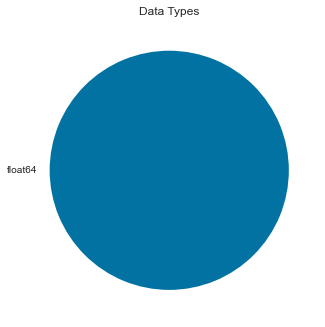

In [80]:
plt.figure()
df.dtypes.value_counts().plot.pie(ylabel='')
plt.title('Data Types')
plt.show()

정규화와 표준화를 거쳤기 때문에, 모두 실수 형태인 float64로 저장된 것을 확인할 수 있습니다.

데이터의 크기에 따라 데이터 형태를 다르게 하여 저장해보겠습니다.

In [81]:
def downcast_dtypes(df):     
    start_mem = df.memory_usage().sum() / 1024**2
    print(('데이터의 크기는 {:.2f}' 
                     'MB 입니다.').format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')
    end_mem = df.memory_usage().sum() / 1024**2
    print(('다운캐스트 후 데이터의 크기는: {:.2f}' 
                              'MB 입니다.').format(end_mem))
    print('데이터를 {:.1f}% 축소했습니다.'.format(100 * (start_mem - end_mem) / start_mem))
    return df

In [82]:
df = downcast_dtypes(df)
display(df)

데이터의 크기는 0.02MB 입니다.
다운캐스트 후 데이터의 크기는: 0.01MB 입니다.
데이터를 66.7% 축소했습니다.


,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Has Bandstructure,Crystal System
0,-1.255859,-0.022034,-1.752930,0.839355,-0.295654,0.228882,0.486328,-1.162109
1,-1.164062,0.233643,1.178711,0.700684,1.087891,0.748535,0.486328,-1.162109
2,-1.072266,0.957031,-0.105896,-1.566406,-1.030273,0.293701,0.486328,-0.036530
3,-1.072266,-0.914062,-0.731445,0.474609,1.779297,0.754395,-2.050781,-0.036530
4,-0.980469,-1.980469,1.145508,0.521484,2.125000,-0.500000,-2.050781,-1.162109
...,...,...,...,...,...,...,...,...
334,-0.338867,-0.022034,-1.752930,0.870605,-0.987305,0.251465,0.486328,1.088867
335,-0.889160,-0.381104,-0.171753,1.059570,-0.728027,-0.347412,0.486328,1.088867
336,1.861328,-0.402832,-1.456055,0.811035,-0.987305,-0.288086,0.486328,-1.162109
337,-1.072266,1.490234,-1.126953,0.358643,0.266357,1.198242,0.486328,-0.036530


데이터 자료형의 비율을 살펴봅니다. 모든 float64 자료형이 flaot16으로 압축되었습니다.


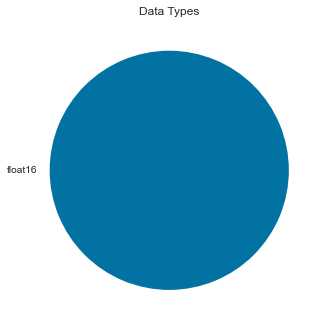

In [83]:
plt.figure()
df.dtypes.value_counts().plot.pie(ylabel='')
plt.title('Data Types')
plt.show()

---
### 6.3 데이터 저장
전처리가 모두 끝난 압축 데이터를 csv 형태로 저장하여 관리합니다.


In [84]:
df.to_csv('./data/processed.csv')

processed.csv 라는 이름으로 데이터를 저장합니다.